# True parameters at 1 PA model
```python
m1 = 1e6
m2 = 1e1
a = 0.8
e0 = 0.4
xI0 = 1.0
dist = 0.5 
qS = np.pi/4
phiS = 1.0
qK = 1 
phiK = np.pi/3

Phi_phi0 = 0.9
Phi_theta0 =0.5
Phi_r0 = 0.4

dt = 10.0
T = 1.0

chi2 = 0.9

dev_C_p=0.0
dev_C_e=0.0


evolve_1PA = False
evolve_primary = False
evolve_2PA = False
deviation_included=True
p0=7.5
best_fit = [13.81562975,10.00108591,0.80008239,7.49955089,0.39996359,0.7889396,1.00931468,0.97747737,0.35608951,1.26255293,-1.44475749]

```

In [1]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt

from itertools import product
import os
import h5py
from tqdm import tqdm
import pandas as pd

#few utils
from few.utils.utility import get_p_at_t
from few.utils.constants import MTSUN_SI
from few.utils.geodesic import get_fundamental_frequencies
#few trajectory
from few.trajectory.inspiral import EMRIInspiral
from few.trajectory.ode.flux import SuperKludgeFlux
#few waveform
from few.waveform import FastKerrEccentricEquatorialFlux, GenerateEMRIWaveform
from few.waveform.waveform import SuperKludgeWaveform
from few.utils.constants import YRSID_SI

#sef imports
from stableemrifisher.fisher import StableEMRIFisher
from stableemrifisher.utils import generate_PSD, padding, inner_product
from stableemrifisher.fisher.derivatives import derivative
from stableemrifisher.fisher.stablederivative import StableEMRIDerivative
from stableemrifisher.noise import sensitivity_LWA

#lisa-on-gpu import
from fastlisaresponse import ResponseWrapper  # Response function 

#LISAanalysistools imports
from lisatools.detector import ESAOrbits, EqualArmlengthOrbits #ESAOrbits correspond to esa-trailing-orbits.h5, EqualArmlengthOrbits are equalarmlength-orbits.h5
from lisatools.sensitivity import get_sensitivity, A1TDISens, E1TDISens, T1TDISens
from lisatools.sensitivity import get_sensitivity,CornishLISASens

use_gpu = True
from parismc.sampler import SamplerConfig
from parismc.sampler import Sampler

from smt.sampling_methods import LHS

if not use_gpu:
    
    import few
    
    #tune few configuration
    cfg_set = few.get_config_setter(reset=True)
    cfg_set.enable_backends("cpu")
    cfg_set.set_log_level("info");

else:
    pass #let the backend decide for itself



if(use_gpu):
    xp=cp
else:
    xp=np

startup


In [2]:
#waveform class setup
waveform_class = SuperKludgeWaveform
max_step_days = 10.0 #max trajectory step size in days
inspiral_kwargs = {
    "err":1e-11, #default = 1e-11
    "max_step_size":max_step_days*24*60*60, #in seconds
}
sum_kwargs = {
    "pad_output": True, # True if expecting waveforms smaller than LISA observation window.
}

waveform_class_kwargs = dict(inspiral_kwargs=inspiral_kwargs,
                              mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                              sum_kwargs=sum_kwargs,
                              use_gpu=use_gpu)

waveform_generator = GenerateEMRIWaveform
waveform_generator_kwargs = dict(return_list=False)

In [3]:
if(use_gpu):
    xp=cp
else:
    xp=np
best_fit = [13.81562975,10.00108591,0.80008239,7.49955089,0.39996359,0.7889396,1.00931468,0.97747737,0.35608951,1.26255293,-1.44475749]
logm1 = best_fit[0]
m1= np.exp(logm1)
m2 = best_fit[1]
a = best_fit[2]
p0= best_fit[3]
e0 = best_fit[4]
xI0 = 1.0
dist = 0.5
qS = best_fit[5]
phiS = best_fit[6]
qK = 1 
phiK = np.pi/3
Phi_phi0 = best_fit[7]
Phi_theta0 =0.5
Phi_r0 = best_fit[8]

dt = 10.0
T = 1.0

chi2 = 0.9

dev_C_p= best_fit[9]
dev_C_e= best_fit[10]

evolve_1PA = False
evolve_primary = False
evolve_2PA = False
deviation_included=True


print(use_gpu)

pars_list_snr = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,\
              chi2,evolve_1PA,evolve_primary,evolve_2PA,deviation_included,dev_C_p,dev_C_e,]

pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

pars_list_com = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0,\
             chi2,evolve_1PA,evolve_primary,evolve_2PA,deviation_included,dev_C_p,dev_C_e]

add_param_args={"chi2":chi2,"evolve_1PA":evolve_1PA,"evolve_primary":evolve_primary,"evolve_2PA":evolve_2PA,"deviation_included":deviation_included,"devCp":dev_C_p,
"devCe":dev_C_e}

emri_kwargs = {"T":T, "dt":dt}

True


In [4]:
der_order = 8
Ndelta=16
sef = StableEMRIFisher(waveform_class=waveform_class, 
                       waveform_class_kwargs=waveform_class_kwargs,
                       waveform_generator=waveform_generator,
                       waveform_generator_kwargs=waveform_generator_kwargs,
                       stats_for_nerds = True, use_gpu = use_gpu,
                       deriv_type='stable',
                       noise_model=get_sensitivity,
                       noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                       channels=["A","E"],
                       T = T, dt = dt,
                       stability_plot = False,
                       der_order = der_order, Ndelta = Ndelta,
                       plunge_check=True, return_derivatives=False
                       )
                   

SNR = sef.SNRcalc_SEF(*pars_list_com,**emri_kwargs,use_gpu=use_gpu)
print("SNR: ", SNR)

waveform shape: (2, 3155815)
wave ndim: 2
Computing SNR for parameters: (np.float64(1000119.1991393781), 10.00108591, 0.80008239, 7.49955089, 0.39996359, 1.0, 0.5, 0.7889396, 1.00931468, 1, 1.0471975511965976, 0.97747737, 0.5, 0.35608951, 0.9, False, False, False, True, 1.26255293, -1.44475749)
SNR:  109.56288335761433


Body is not plunging, Fisher should be stable.
waveform shape: (2, 3155815)
wave ndim: 2
Computing SNR for parameters: (np.float64(1000119.1991393781), 10.00108591, 0.80008239, 7.49955089, 0.39996359, 1.0, 0.5, 0.7889396, 1.00931468, 1, 1.0471975511965976, 0.97747737, 0.5, 0.35608951, 0.9, False, False, False, True, 1.26255293, -1.44475749)
Waveform Generated. SNR: 109.56288335761433
calculating stable deltas...
Gamma_ii for m1: 14256.79564139614
Gamma_ii for m1: 14256.795730430635
Gamma_ii for m1: 14256.795599127123
Gamma_ii for m1: 14256.794463539321
Gamma_ii for m1: 14256.796248501678
Gamma_ii for m1: 14256.797578340087
Gamma_ii for m1: 14256.803667136177
Gamma_ii for m1: 14256.817323991323
Gamma_ii for m1: 14256.763775001358
Gamma_ii for m1: 14256.838631739558
Gamma_ii for m1: 14256.472386112866
Gamma_ii for m1: 14257.091583785956
Gamma_ii for m1: 14255.075782798507
Gamma_ii for m1: 14257.69387043996
Gamma_ii for m1: 14257.294404084287
Gamma_ii for m1: 14254.141071482232
[np.float6

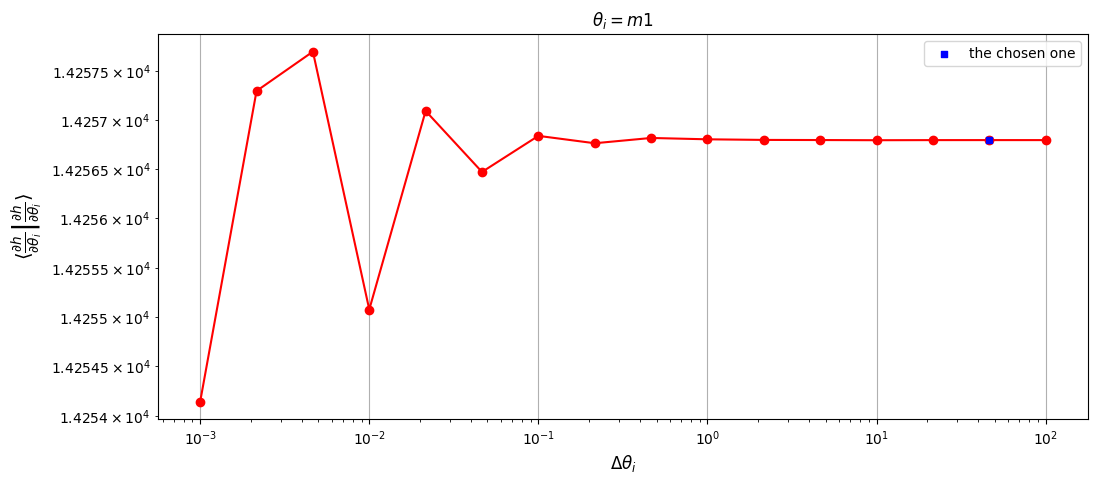

Gamma_ii for m2: 9091416940165.021
Gamma_ii for m2: 9091417338003.768
Gamma_ii for m2: 9091416938927.96
Gamma_ii for m2: 9091416824306.816
Gamma_ii for m2: 9091419028127.744
Gamma_ii for m2: 9091408725008.484
Gamma_ii for m2: 9091409160520.582
Gamma_ii for m2: 9091404111107.363
Gamma_ii for m2: 9091460748930.723
Gamma_ii for m2: 9091361732669.146
Gamma_ii for m2: 9091196270395.248
Gamma_ii for m2: 9091656483035.604
Gamma_ii for m2: 9087115767887.354
Gamma_ii for m2: 9093311456156.514
Gamma_ii for m2: 9093551556639.006
Gamma_ii for m2: 9085427546260.615
[np.float64(4.375981558240783e-08), np.float64(4.389588656217576e-08), np.float64(1.2607621754268142e-08), np.float64(2.4240670470869523e-07), np.float64(1.1332808337418588e-06), np.float64(4.7903695672114286e-08), np.float64(5.554052110147554e-07), np.float64(6.229782531485533e-06), np.float64(1.0891246491750972e-05), np.float64(1.820027518680376e-05), np.float64(5.061922887365943e-05), np.float64(0.0004996871685399099), np.float64(0.00

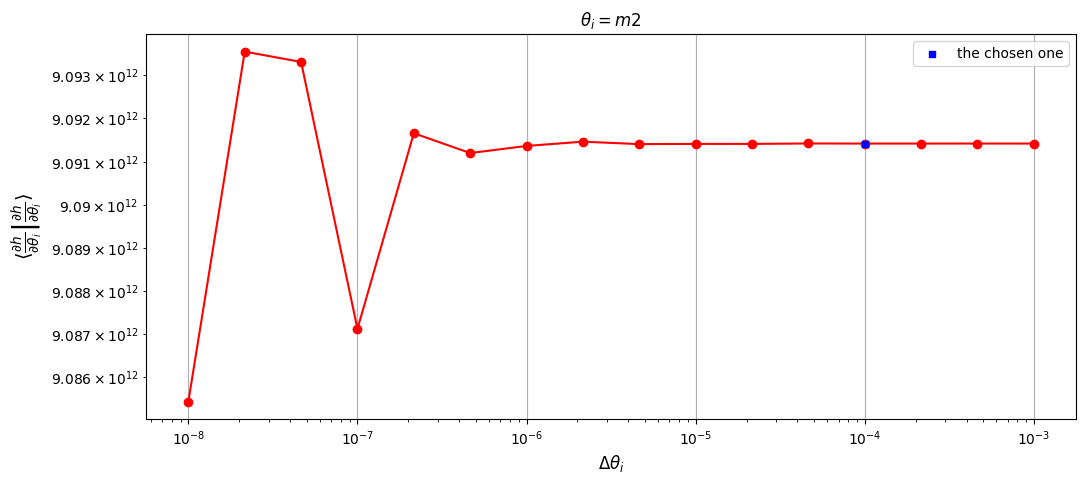

Gamma_ii for a: 1163819013390841.0
Gamma_ii for a: 1163819027468940.5
Gamma_ii for a: 1163819142348205.0
Gamma_ii for a: 1163818775087889.5
Gamma_ii for a: 1163820046074996.8
Gamma_ii for a: 1163819086937874.5
Gamma_ii for a: 1163818707599091.0
Gamma_ii for a: 1163813281375314.5
Gamma_ii for a: 1163812423257411.5
Gamma_ii for a: 1163835865613497.0
Gamma_ii for a: 1163787008924827.5
Gamma_ii for a: 1163776718707737.8
Gamma_ii for a: 1163979106579474.5
Gamma_ii for a: 1162907586397217.8
Gamma_ii for a: 1161856307121352.2
Gamma_ii for a: 1159275182786524.8
[np.float64(1.209646789382442e-08), np.float64(9.870886319004115e-08), np.float64(3.1556486573458585e-07), np.float64(1.0920821578356775e-06), np.float64(8.241290532307616e-07), np.float64(3.2594319117155276e-07), np.float64(4.6624521848450314e-06), np.float64(7.373335134180827e-07), np.float64(2.014232142016241e-05), np.float64(4.198078195995381e-05), np.float64(8.842088799624981e-06), np.float64(0.0001738758630569382), np.float64(0.00

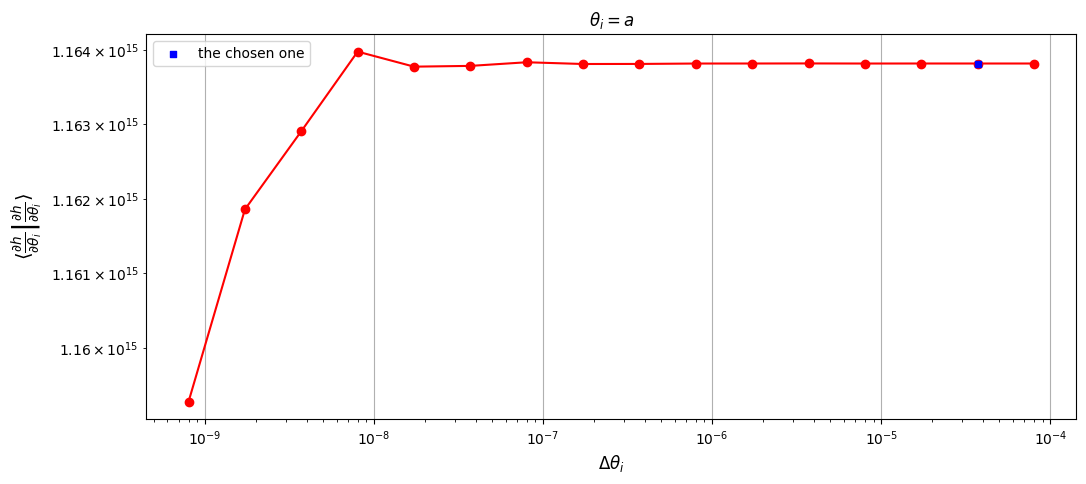

Gamma_ii for p0: 751739217117730.6
Gamma_ii for p0: 751739224355194.9
Gamma_ii for p0: 751739230996010.2
Gamma_ii for p0: 751739224442319.4
Gamma_ii for p0: 751739278414241.8
Gamma_ii for p0: 751739228726996.9
Gamma_ii for p0: 751739513590265.4
Gamma_ii for p0: 751739111001059.5
Gamma_ii for p0: 751739257513428.0
Gamma_ii for p0: 751737948417609.5
Gamma_ii for p0: 751733344018140.1
Gamma_ii for p0: 751745582311361.6
Gamma_ii for p0: 751706199834630.1
Gamma_ii for p0: 751786579873419.9
Gamma_ii for p0: 751726543549839.2
Gamma_ii for p0: 751838010625227.5
[np.float64(9.62762619737974e-09), np.float64(8.833934828971624e-09), np.float64(8.718037667732293e-09), np.float64(7.179606537103024e-08), np.float64(6.609638419314753e-08), np.float64(3.7893879907883136e-07), np.float64(5.355437810584164e-07), np.float64(1.9489785458940584e-07), np.float64(1.7414257471710927e-06), np.float64(6.125043549037903e-06), np.float64(1.627983390852982e-05), np.float64(5.239078344726152e-05), np.float64(0.0001

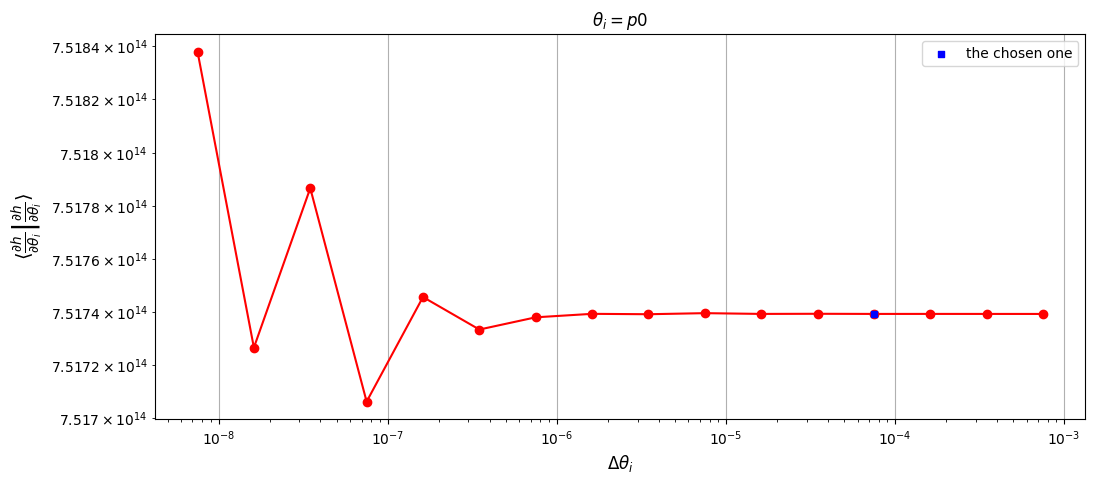

Gamma_ii for e0: 2445914114021751.5
Gamma_ii for e0: 2445914073232487.5
Gamma_ii for e0: 2445914322877841.5
Gamma_ii for e0: 2445913944286412.0
Gamma_ii for e0: 2445913187531774.5
Gamma_ii for e0: 2445911684332211.0
Gamma_ii for e0: 2445908063562413.5
Gamma_ii for e0: 2445910862650228.0
Gamma_ii for e0: 2445885654522764.5
Gamma_ii for e0: 2445871222924774.5
Gamma_ii for e0: 2445860455688569.0
Gamma_ii for e0: 2446141091949064.5
Gamma_ii for e0: 2444817746655944.0
Gamma_ii for e0: 2444083759207967.5
Gamma_ii for e0: 2458561480927405.0
Gamma_ii for e0: 2450103406867104.5
[np.float64(1.6676490988129215e-08), np.float64(1.0206627095027166e-07), np.float64(1.547852615110925e-07), np.float64(3.093955424737122e-07), np.float64(6.145763860277757e-07), np.float64(1.4803376510507207e-06), np.float64(1.1443948580640804e-06), np.float64(1.0306339307762345e-05), np.float64(5.900391588377529e-06), np.float64(4.402228336640228e-06), np.float64(0.0001147261134769178), np.float64(0.0005412858667811089)

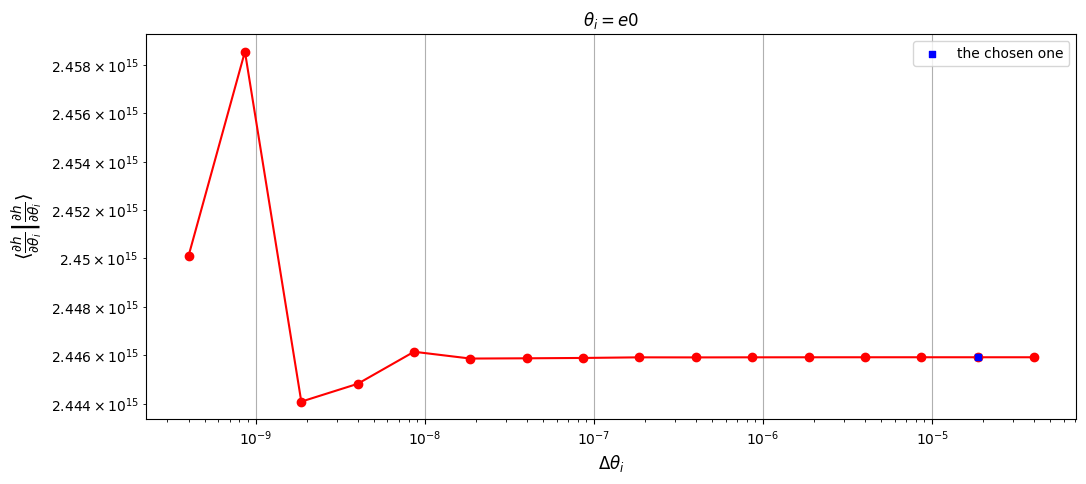

Gamma_ii for qS: 26950.2538177515
Gamma_ii for qS: 26950.25388114796
Gamma_ii for qS: 26950.253881287248
Gamma_ii for qS: 26950.25388128742
Gamma_ii for qS: 26950.253881286935
Gamma_ii for qS: 26950.253881288405
Gamma_ii for qS: 26950.253881286506
Gamma_ii for qS: 26950.253881280878
Gamma_ii for qS: 26950.253881283457
Gamma_ii for qS: 26950.253881301793
Gamma_ii for qS: 26950.253881276425
Gamma_ii for qS: 26950.25388111825
Gamma_ii for qS: 26950.25388129354
Gamma_ii for qS: 26950.253881559936
Gamma_ii for qS: 26950.253880873843
Gamma_ii for qS: 26950.253881251534
[np.float64(2.3523510922717367e-09), np.float64(5.168311037093188e-12), np.float64(6.344467279843767e-15), np.float64(1.7953492515302896e-14), np.float64(5.453542087354868e-14), np.float64(7.046408340592678e-14), np.float64(2.0882746557278062e-13), np.float64(9.570696385978493e-14), np.float64(6.803428742637347e-13), np.float64(9.412759647312475e-13), np.float64(5.86917218855444e-12), np.float64(6.5042938598281405e-12), np.flo

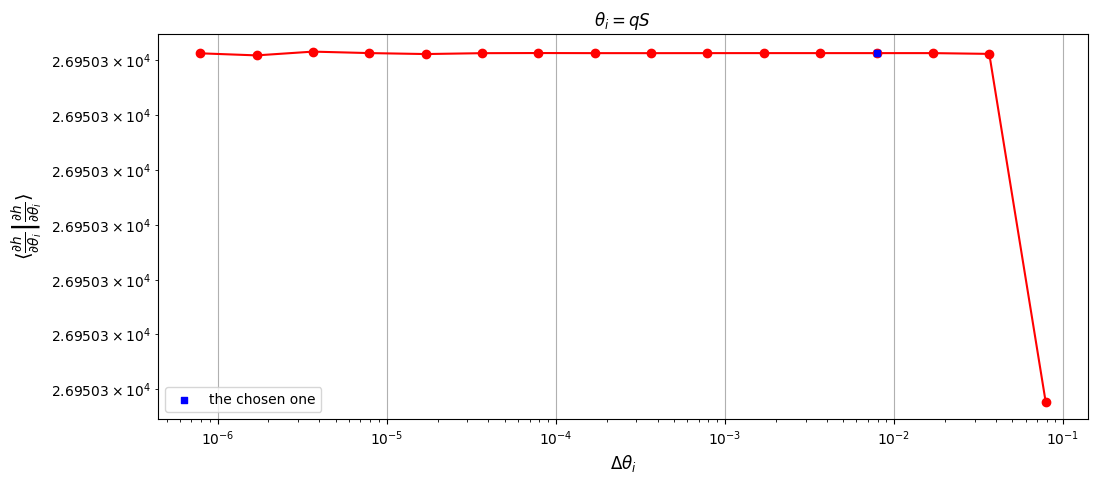

Gamma_ii for phiS: 747746.5633838084
Gamma_ii for phiS: 747746.5633622283
Gamma_ii for phiS: 747746.5633621806
Gamma_ii for phiS: 747746.5633621805
Gamma_ii for phiS: 747746.5633621805
Gamma_ii for phiS: 747746.5633621805
Gamma_ii for phiS: 747746.5633621805
Gamma_ii for phiS: 747746.5633621805
Gamma_ii for phiS: 747746.5633621806
Gamma_ii for phiS: 747746.563362181
Gamma_ii for phiS: 747746.5633621819
Gamma_ii for phiS: 747746.5633621805
Gamma_ii for phiS: 747746.5633621797
Gamma_ii for phiS: 747746.5633621721
Gamma_ii for phiS: 747746.5633621885
Gamma_ii for phiS: 747746.5633622457
[np.float64(2.8860078641279955e-11), np.float64(6.383216491751966e-14), np.float64(1.5568820711590163e-16), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(1.556882071159016e-16), np.float64(4.670646213477046e-16), np.float64(1.2455056569272107e-15), np.float64(1.8682584853908194e-15), np.float64(1.0898174498113126e-15), np.float64(1.011973346253372e-14), np.float64(2.1952037

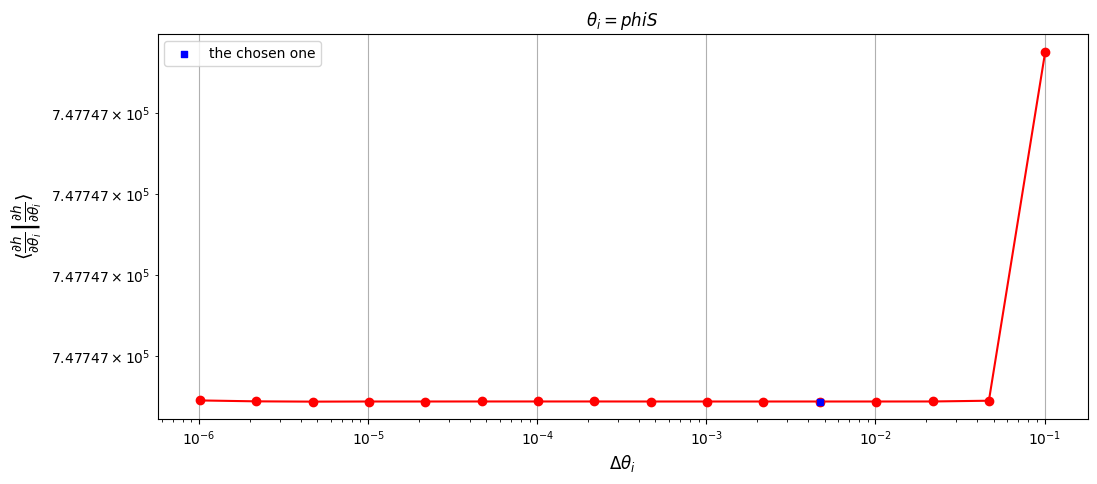

Gamma_ii for devCp: 5004.455417647473
Gamma_ii for devCp: 5004.406564818338
Gamma_ii for devCp: 5004.477811347297
Gamma_ii for devCp: 5004.107929037392
Gamma_ii for devCp: 5004.302827509156
Gamma_ii for devCp: 5002.134685273562
Gamma_ii for devCp: 5000.17426044017
Gamma_ii for devCp: 5007.615983918248
Gamma_ii for devCp: 4989.163111872262
Gamma_ii for devCp: 5007.49785385537
Gamma_ii for devCp: 4966.910037830269
Gamma_ii for devCp: 4573.215968297503
Gamma_ii for devCp: 5323.363387926623
Gamma_ii for devCp: 5555.101126763394
Gamma_ii for devCp: 3346.817477468054
Gamma_ii for devCp: 8021.640702096309
[np.float64(9.761962482969921e-06), np.float64(1.4236556069319084e-05), np.float64(7.391573386307357e-05), np.float64(3.894617861500295e-05), np.float64(0.0004334433940725946), np.float64(0.0003920713021749826), np.float64(0.0014860811016614126), np.float64(0.003698590651822144), np.float64(0.0036614577815528545), np.float64(0.008171643077077092), np.float64(0.0860869183222345), np.float64(0

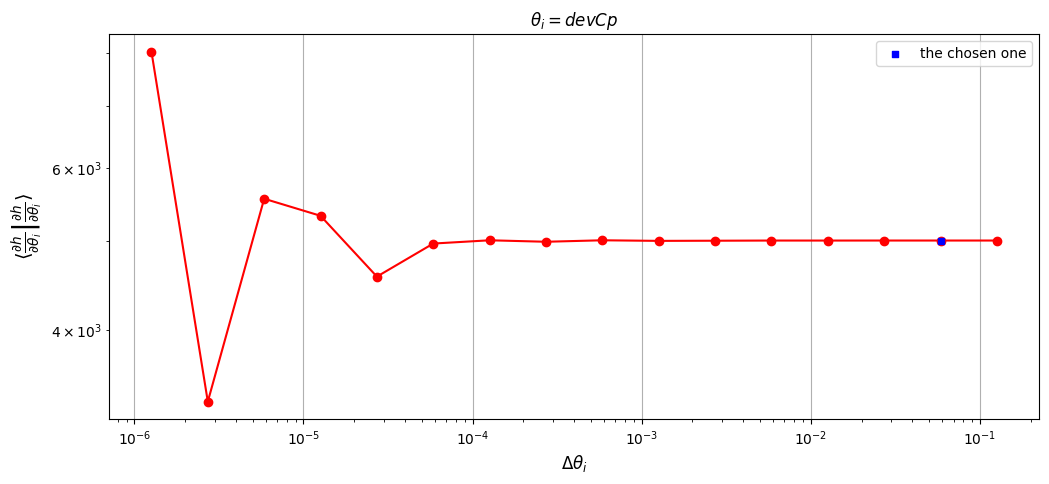

Gamma_ii for devCe: 32695.257307836328
Gamma_ii for devCe: 32695.22591527205
Gamma_ii for devCe: 32695.803672289865
Gamma_ii for devCe: 32695.52742314476
Gamma_ii for devCe: 32693.36995051081
Gamma_ii for devCe: 32694.678320676314
Gamma_ii for devCe: 32704.666298059063
Gamma_ii for devCe: 32692.63753122103
Gamma_ii for devCe: 32761.899325406517
Gamma_ii for devCe: 32604.178759963106
Gamma_ii for devCe: 32619.998818544784
Gamma_ii for devCe: 32262.079014268482
Gamma_ii for devCe: 31693.595179957087
Gamma_ii for devCe: 33358.95688229618
Gamma_ii for devCe: 21150.07155040109
Gamma_ii for devCe: 35917.850512669844
[np.float64(9.601574357708785e-07), np.float64(1.767067797461572e-05), np.float64(8.449141729126846e-06), np.float64(6.599113634401587e-05), np.float64(4.00178326476336e-05), np.float64(0.0003053991528830109), np.float64(0.0003679350381732286), np.float64(0.002114095812869311), np.float64(0.004837434078759465), np.float64(0.00048498035422011514), np.float64(0.01109413327386637), 

/home/svu/e1583490/scratch/StableEMRIFisher/stableemrifisher/plot.py:163: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  plt.scatter(
/home/svu/e1583490/anaconda3/envs/few_gpu/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Data has no positive values, and therefore cannot be log-scaled.
  fig.canvas.print_figure(bytes_io, **kw)


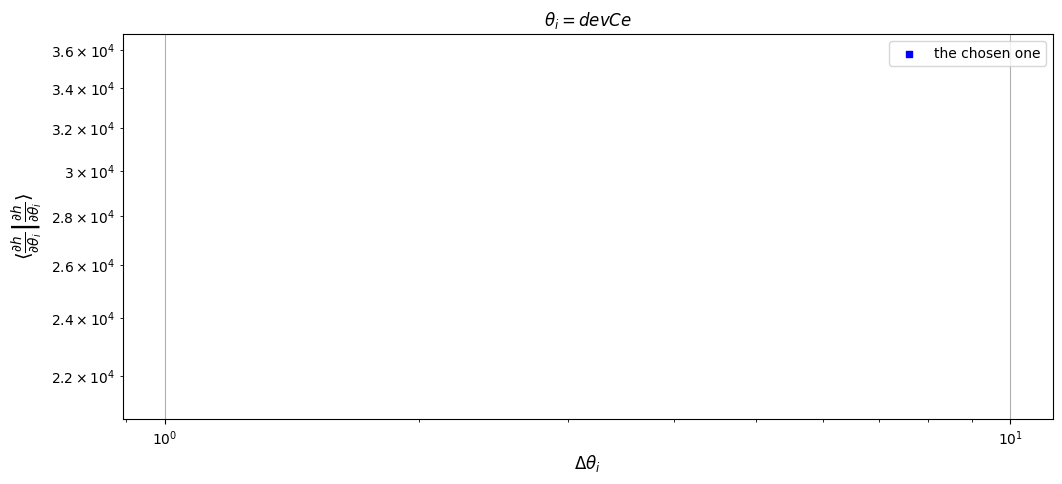

stable deltas: {'m1': 46.42142107007095, 'm2': 0.00010001085909999995, 'a': 3.713653487394226e-05, 'p0': 7.49955089000001e-05, 'e0': 1.8564665331956806e-05, 'qS': 0.007889395999999996, 'phiS': 0.004684823748289457, 'Phi_phi0': 0.0, 'Phi_r0': 0.0, 'devCp': 0.05860251581733096, 'devCe': -0.06705970232862428}
Time taken to compute stable deltas is 316.0562207698822 seconds
calculating Fisher matrix...
Finished derivatives
Calculated Fisher is *atleast* positive-definite.
Time taken to compute FM is 21.138658046722412 seconds


In [5]:
param_names = ['m1','m2','a','p0','e0','qS','phiS','Phi_phi0','Phi_r0','devCp','devCe']
pars_list = [m1, m2, a, p0, e0, xI0, dist, qS, phiS, qK, phiK, Phi_phi0, Phi_theta0, Phi_r0]

param_dict = {
    'm1': m1,
    'm2': m2,
    'a': a,
    'p0': p0,
    'e0': e0,
    'xI0': xI0,
    'dist': dist,
    'qS': qS,
    'phiS': phiS,
    'qK': qK,
    'phiK': phiK,
    'Phi_phi0': Phi_phi0,
    'Phi_theta0': Phi_theta0,
    'Phi_r0': Phi_r0
}


Fisher = sef(wave_params = param_dict,param_names=param_names, add_param_args=add_param_args,
            live_dangerously = False, stability_plot = True,der_order = der_order, Ndelta = Ndelta,return_derivatives=True
            )


In [6]:
def logmasstransform(Fisher, m1, index_of_m1 = 0):    
    J = np.eye(len(Fisher))
    J[index_of_m1,index_of_m1] = m1
    
    return J.T@Fisher@J
fisher_=logmasstransform(Fisher[-1], m1, index_of_m1 = 0)
cov=np.linalg.inv(fisher_)
std= np.sqrt(np.diag(cov))
params_truth_in = np.array([np.log(1e6), 10, 0.8, 7.5, 0.4, np.pi/4, 1.0,  0.9,0.4,0,0])

In [7]:
from scipy.stats import chi2
def plot_confidence_ellipse(ax, mean, cov, i, j, levels=[0.90, 0.99]):

    # Extract 2x2 sub-covariance
    cov2 = cov[np.ix_([i, j], [i, j])]
    mean2 = mean[[i, j]]
    
    # Eigen decomposition
    eigvals, eigvecs = np.linalg.eigh(cov2)
    order = np.argsort(eigvals)[::-1]
    eigvals = eigvals[order]
    eigvecs = eigvecs[:, order]

    theta = np.linspace(0, 2*np.pi, 400)

    for p in levels:
        chi2_val = chi2.ppf(p, df=2)
        r1 = np.sqrt(eigvals[0] * chi2_val)
        r2 = np.sqrt(eigvals[1] * chi2_val)
        
        ellipse = np.vstack([r1*np.cos(theta), r2*np.sin(theta)])
        ellipse = eigvecs @ ellipse + mean2[:, None]

        ax.plot(ellipse[0], ellipse[1], label=f"{int(p*100)}%", lw=1)


# --------------------------------------------------------------------
# Main triangle plot function (WITH LEGEND)
# --------------------------------------------------------------------
def triangle_plot(best_fit, cov, param_truth=None, labels=None,levels=[0.90, 0.99]):
    D = len(best_fit)
    if labels is None:
        labels = [f"p{i}" for i in range(D)]

    fig, axes = plt.subplots(D, D, figsize=(2.2*D, 2.2*D))
    
    legend_ax = axes[-1, -1]  # bottom-right panel for legend only
    legend_handles = []       # store handles for legend

    for i in range(D):
        for j in range(D):

            ax = axes[i, j]

            if i < j:
                ax.axis("off")
                continue

            # ==========================
            # Diagonal panels
            # ==========================
            if i == j:
                ax.axis("off")
                continue
                sigma = np.sqrt(cov[i, i])
                x = np.linspace(best_fit[i] - 4*sigma,
                                best_fit[i] + 4*sigma, 300)
                y = np.exp(-0.5*((x - best_fit[i])/sigma)**2)

                ax.plot(x, y, lw=1.5)

                if param_truth is not None:
                    line_truth = ax.axvline(param_truth[i], color='red', linestyle='--', lw=1)

                ax.set_yticks([])
                ax.set_xlabel(labels[i])

            # ==========================
            # Off-diagonal panels
            # ==========================
            else:
                # Ellipses
                plot_confidence_ellipse(ax, best_fit, cov, j, i,levels=levels)

                # Best-fit point
                bestfit_handle = ax.scatter(best_fit[j], best_fit[i],
                                            color="black", s=12, label="Best-fit")

                # Truth point
                if param_truth is not None:
                    truth_handle = ax.scatter(param_truth[j], param_truth[i],
                                              color="red", marker="x", s=30,
                                              label="Param truth")

                ax.set_xlabel(labels[j])
                ax.set_ylabel(labels[i])

                # Collect handles only once (avoid duplicates)
                if i == D - 1 and j == 0:
                    # ellipse handles (match levels dynamically)
                    level_labels = {f"{int(p*100)}%" for p in levels}
                    for item in ax.get_lines():
                        if item.get_label() in level_labels:
                            legend_handles.append(item)
                
                    legend_handles.append(bestfit_handle)
                    if param_truth is not None:
                        legend_handles.append(truth_handle)

    # Add the legend to bottom-right subplot
    legend_ax.legend(handles=legend_handles, loc="upper right", fontsize=9)
    legend_ax.axis("off")  # hide this subplot except for legend

    plt.tight_layout()
    plt.show()


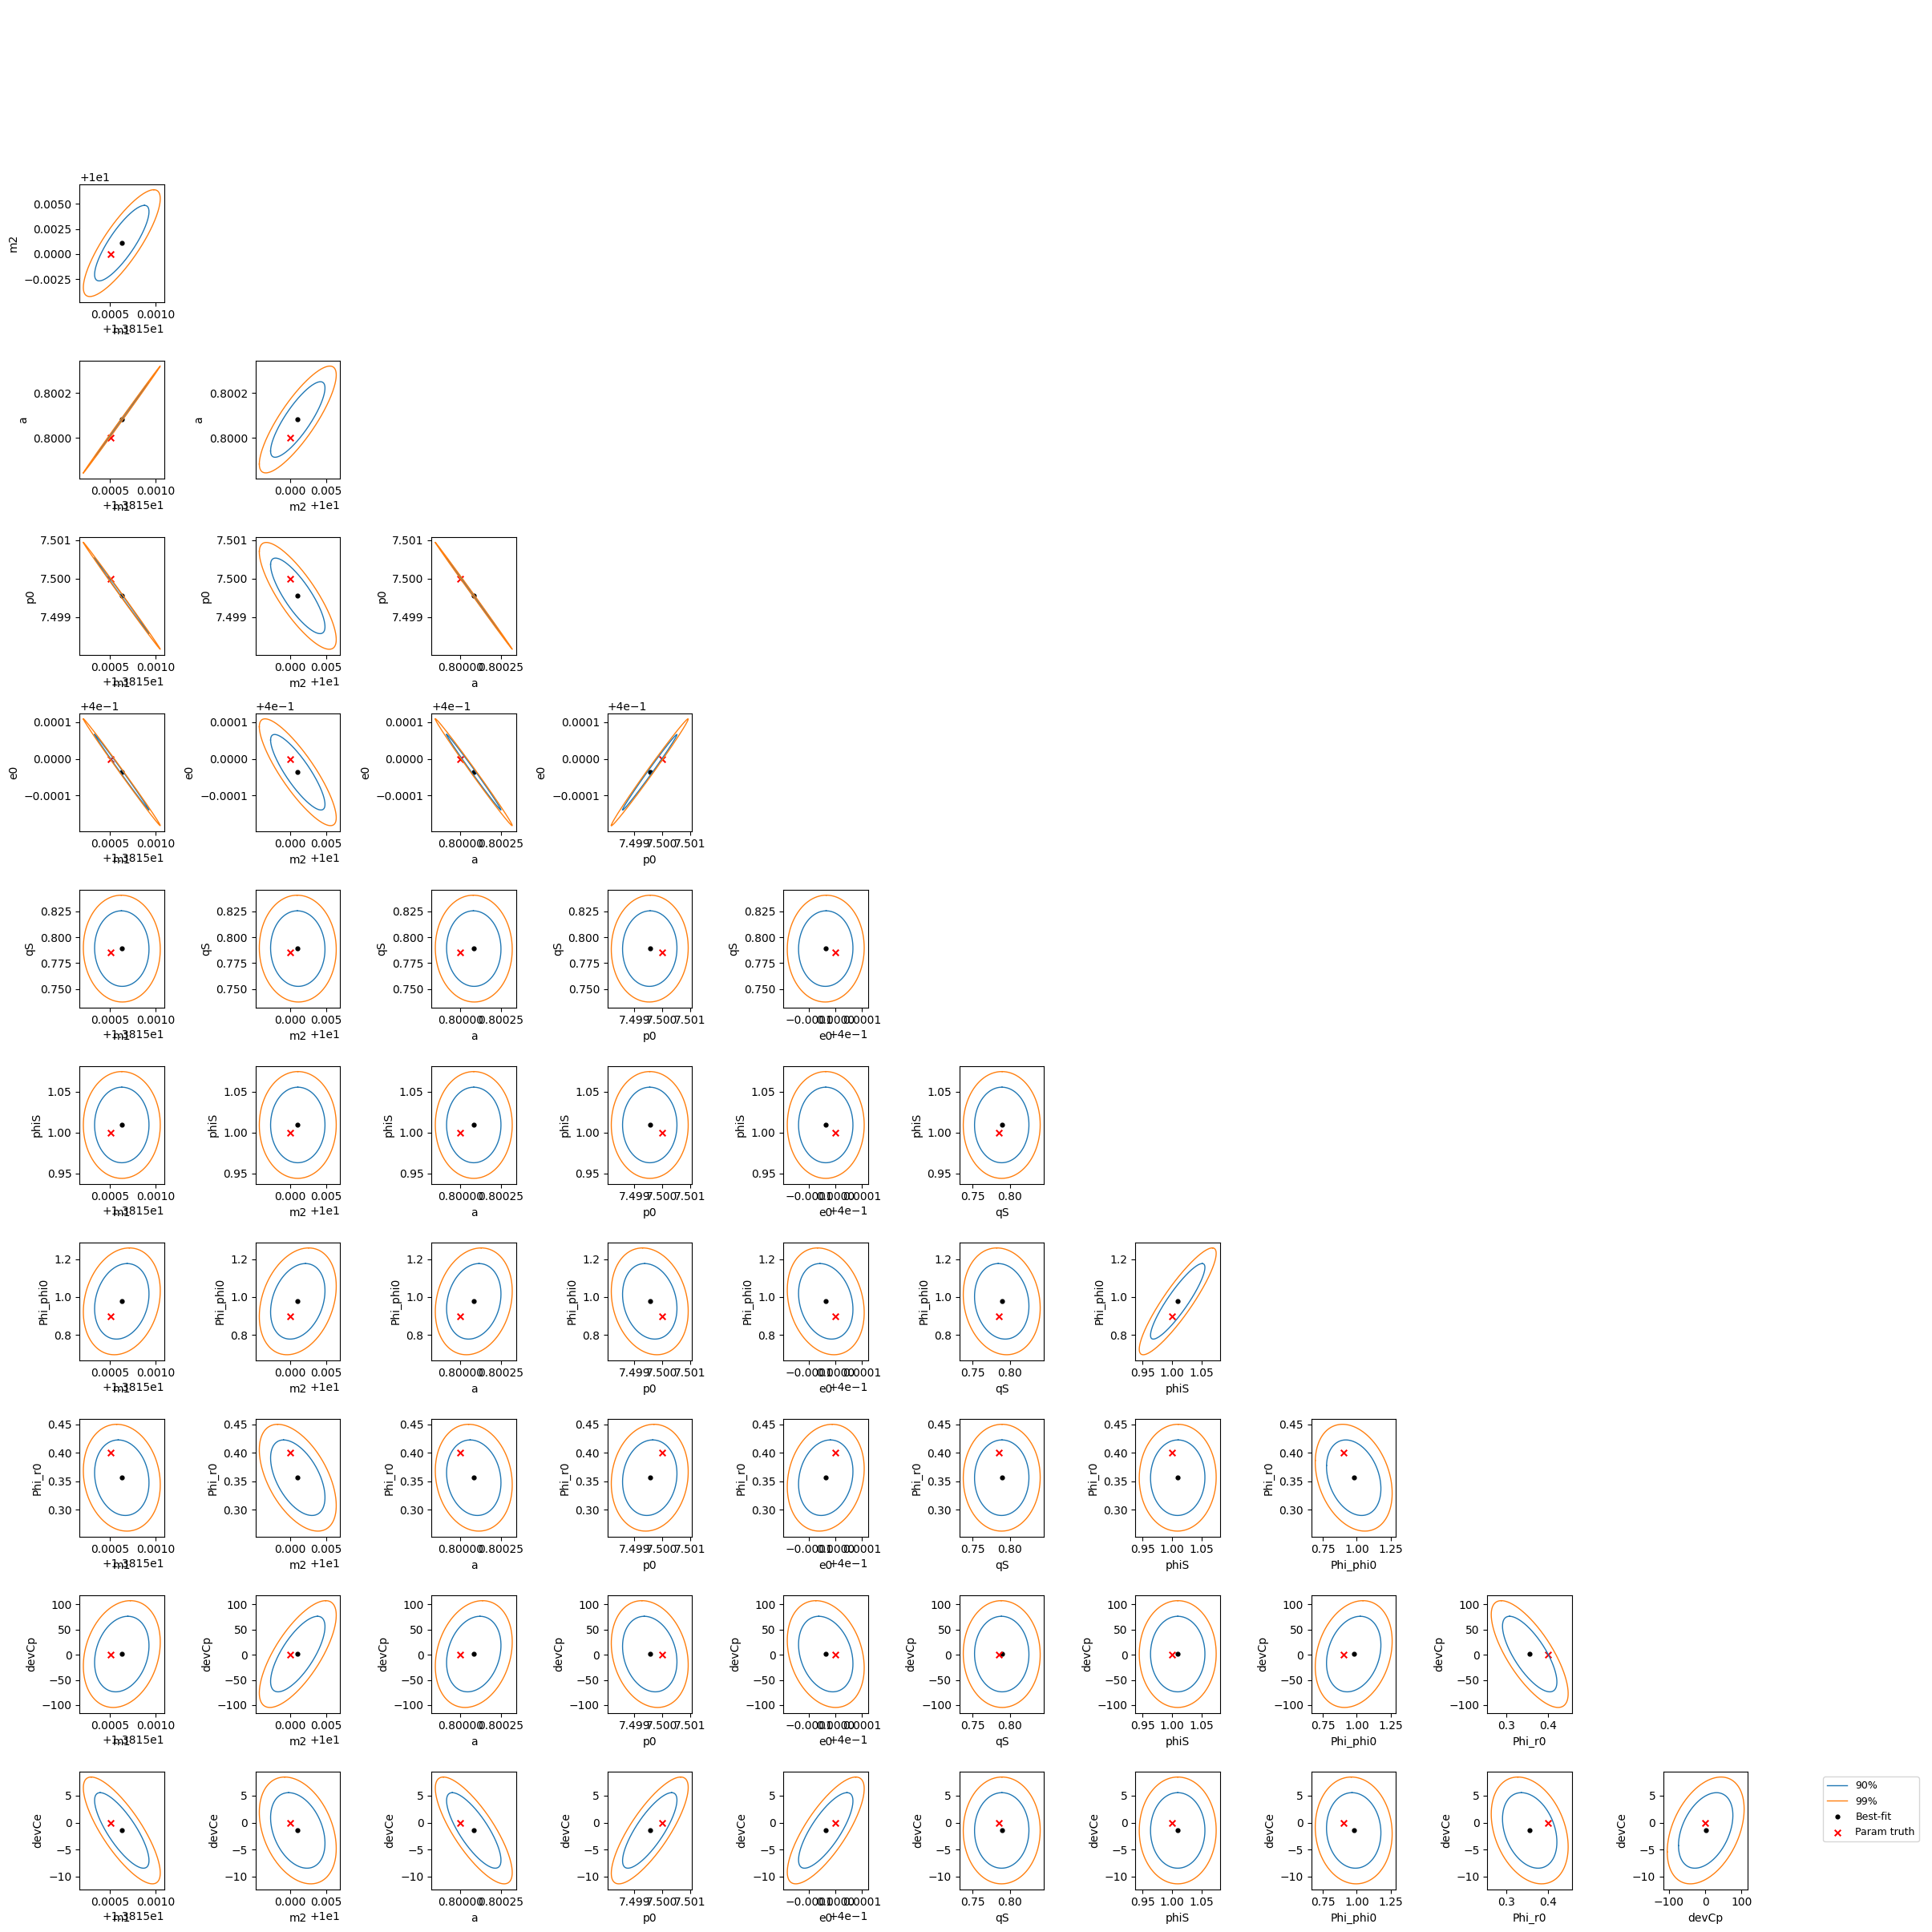

In [8]:
labels = param_names
triangle_plot(np.array(best_fit), cov, np.array(params_truth_in), labels,levels=[0.90, 0.99])

In [9]:
m1_true = 1e6
m2_true = 1e1
a_true = 0.8
e0_true = 0.4
xI0_true = 1.0
dist_true = 0.5 
qS_true = np.pi/4
phiS_true = 1.0
qK_true = 1 
phiK_true = np.pi/3

Phi_phi0_true = 0.9
Phi_theta0_true =0.5
Phi_r0_true = 0.4
p0_true=7.5

dt = 10.0
T = 1.0

chi2 = 0.9

dev_C_p_true=0.0
dev_C_e_true=0.0


evolve_1PA_true = True
evolve_primary = False
evolve_2PA = False
deviation_included=True

superkludge_wave = GenerateEMRIWaveform(SuperKludgeWaveform,\
                                    sum_kwargs=sum_kwargs,\
                                    return_list=True,
                                    mode_selector_kwargs=dict(mode_selection_threshold=1e-5),
                                    inspiral_kwargs=inspiral_kwargs,
                                    use_gpu=use_gpu)
    
add_args = [chi2,evolve_1PA_true,evolve_primary,evolve_2PA,deviation_included,dev_C_p_true,dev_C_e_true]
waveform_true = superkludge_wave(m1_true, m2_true, a_true, p0_true, e0_true, xI0_true, dist_true, qS_true, phiS_true, qK_true, phiK_true, Phi_phi0_true, Phi_theta0_true, Phi_r0_true, *add_args, dt=dt, T=T)
waveform_true= xp.asarray(waveform_true)
fisher_derivs = xp.array(Fisher[0])
fisher_exact = xp.array(Fisher[-1])



In [10]:
# baseline check - 0PA model at true parameters
evolve_1PA_approx = False
add_args = [chi2, evolve_1PA_approx, evolve_primary, evolve_2PA,deviation_included,dev_C_p_true,dev_C_e_true]

waveform_approx = superkludge_wave(m1_true, m2_true, a_true, p0_true, e0_true, xI0_true, dist_true, qS_true, phiS_true, qK_true, phiK_true, Phi_phi0_true, Phi_theta0_true, Phi_r0_true, *add_args, dt=dt, T=T)
waveform_approx= xp.asarray(waveform_approx)

In [11]:
# waveform at best fit parameters with 0PA calaculated during fisher calculation
waveform_best_fit=sef.waveform
waveform_best_fit= xp.asarray(waveform_best_fit)



# waveform analysis and p0 evolution

In [12]:
from few.utils.utility import ( 
    get_mismatch, 
    get_m2_at_t, 
    get_p_at_t, 
    )

from few.utils.geodesic import (
    get_fundamental_frequencies,
    get_separatrix,
    get_kerr_geo_constants_of_motion,
    ELQ_to_pex,
    )
SK_traj = EMRIInspiral(func=SuperKludgeFlux)
#get_p_at_t may fail with SuperKludge, especially with lower eccentricities, so we use KerrEccEq to generate p0 
add_args = [chi2, evolve_1PA_true, evolve_primary, evolve_2PA,deviation_included,dev_C_p,dev_C_e]
p_sep = get_separatrix(a_true, e0_true, xI0_true)
p0_should = get_p_at_t(traj_module=SK_traj, t_out=T, traj_args=[m1_true, m2_true, a_true, e0_true, xI0_true, *add_args])
print('should take p0 around for for true waveform: ', p0_should)
print('separatrix p: ', p_sep)

should take p0 around for for true waveform:  7.406748110569764
separatrix p:  3.3636344376256564


# P evolution is done considering true waveform (1PA)

[0.9, True, False, False, True, 1.26255293, -1.44475749]


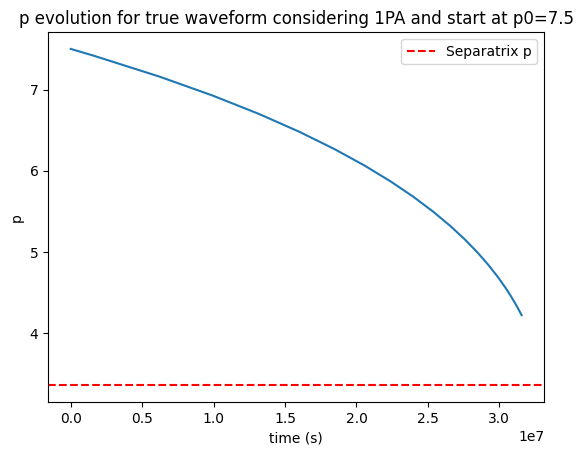

In [13]:
from scipy.interpolate import CubicSpline
add_args = [chi2, evolve_1PA_true, evolve_primary, evolve_2PA,deviation_included,dev_C_p,dev_C_e]
print(add_args) 
t_evol, p_evol, e_evol, x2_evol, pp2_evol, pt2_evol, pr2_evol, _, _ = SK_traj(m1_true, m2_true, a_true, p0_true, e0_true, xI0_true, *add_args,
                                               Phi_phi0=Phi_phi0_true, Phi_theta0=Phi_theta0_true, Phi_r0=Phi_r0_true, T=T, dt=dt)
p_evolution = CubicSpline(t_evol, p_evol)(t_evol)
plt.plot(t_evol, p_evolution)
plt.title('p evolution for true waveform considering 1PA and start at p0=7.5')
plt.xlabel('time (s)')
plt.ylabel('p')
plt.axhline(p_sep, color='red', linestyle='--', label='Separatrix p')
plt.legend()
plt.show()



# Waveform Visualization

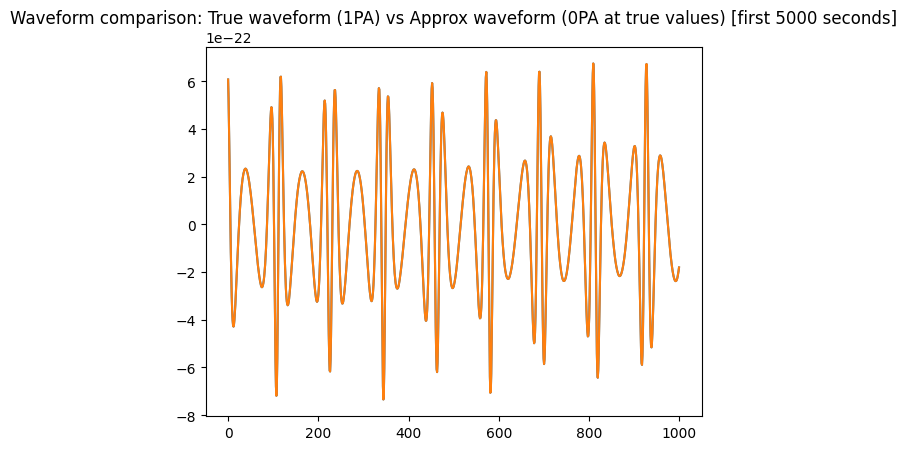

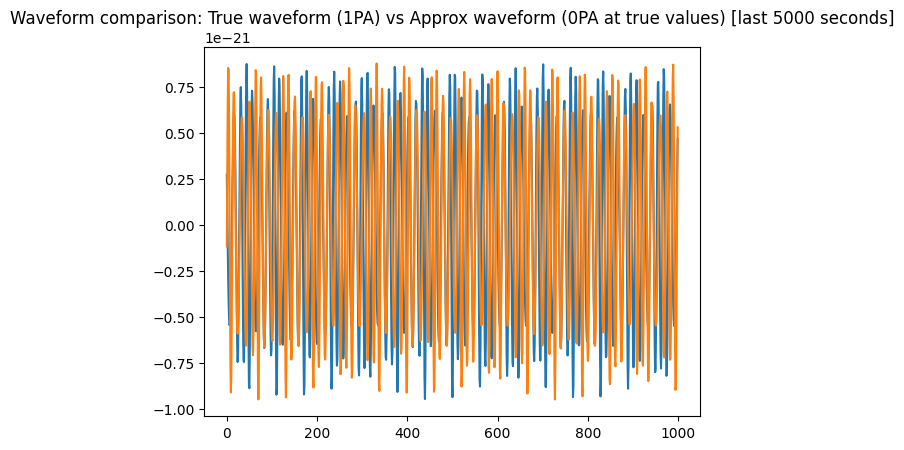

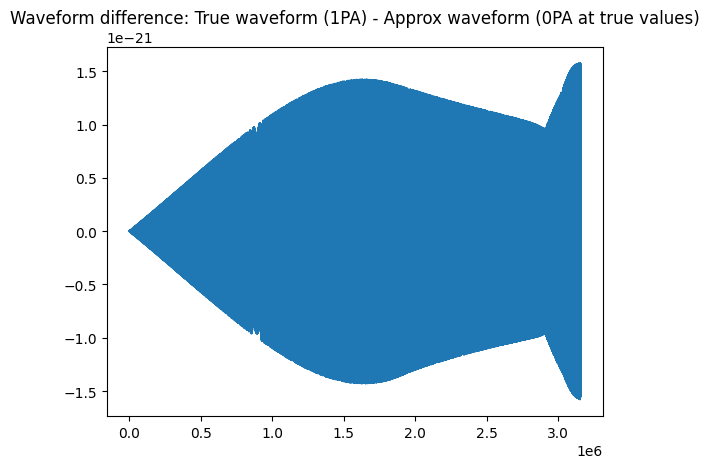

In [14]:
plt.plot(waveform_true[0][0:1000].get())
plt.plot(waveform_approx[0][0:1000].get())
plt.title('Waveform comparison: True waveform (1PA) vs Approx waveform (0PA at true values) [first 5000 seconds]')
plt.show()

plt.plot(waveform_true[0][-1000:].get())
plt.plot(waveform_approx[0][-1000:].get())
plt.title('Waveform comparison: True waveform (1PA) vs Approx waveform (0PA at true values) [last 5000 seconds]')
plt.show()
# waveform_approx
# waveform_best_fit
plt.plot((waveform_true[0]-waveform_approx[0]).get())
plt.title('Waveform difference: True waveform (1PA) - Approx waveform (0PA at true values)')
plt.show()

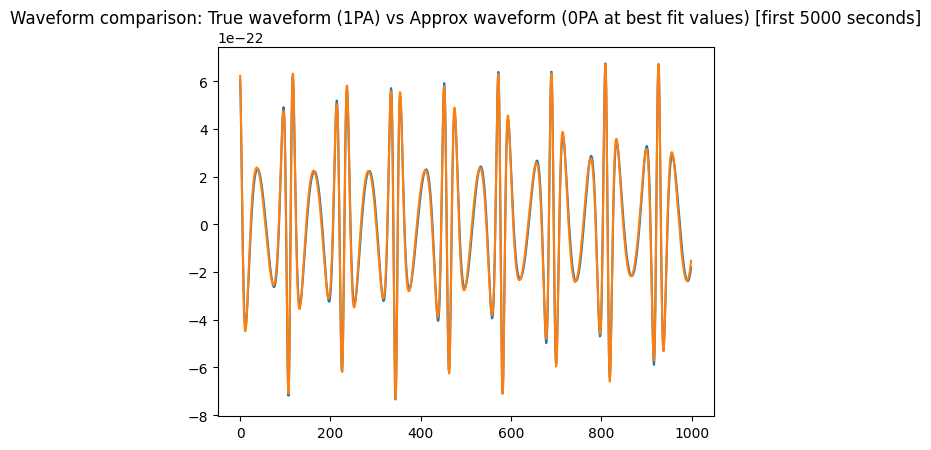

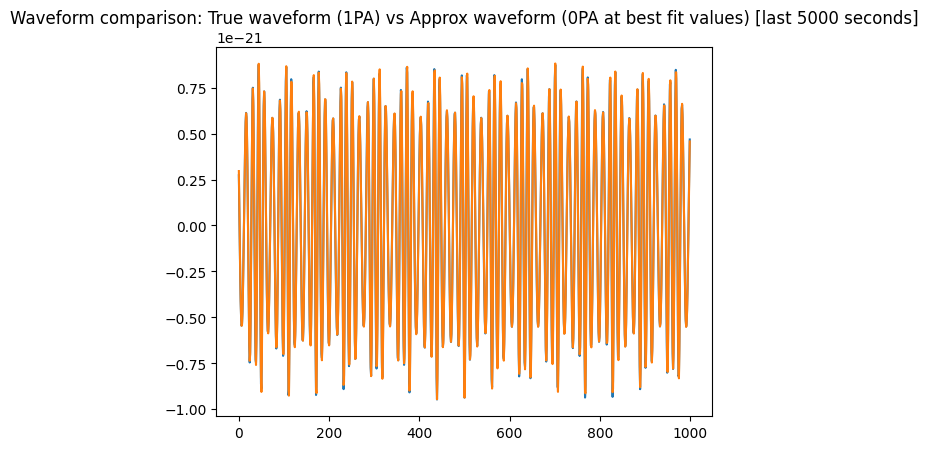

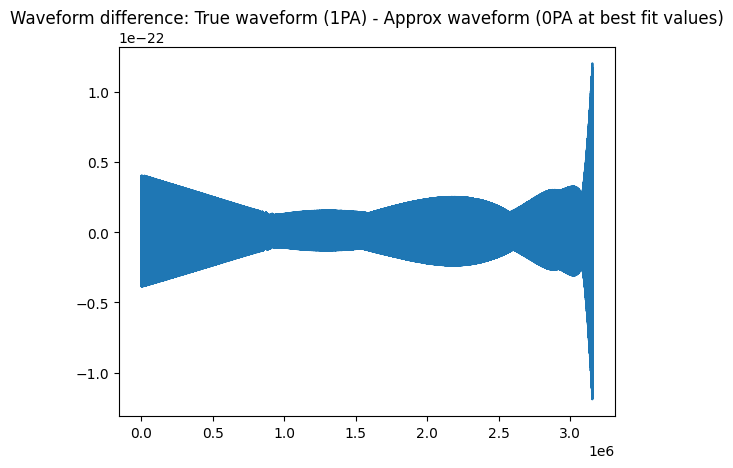

In [15]:
plt.plot(waveform_true[0][0:1000].get())
plt.plot(waveform_best_fit[0][0:1000].get())
plt.title('Waveform comparison: True waveform (1PA) vs Approx waveform (0PA at best fit values) [first 5000 seconds]')
plt.show()

plt.plot(waveform_true[0][-1000:].get())
plt.plot(waveform_best_fit[0][-1000:].get())
plt.title('Waveform comparison: True waveform (1PA) vs Approx waveform (0PA at best fit values) [last 5000 seconds]')
plt.show()
# waveform_approx
# waveform_best_fit
plt.plot((waveform_true[0]-waveform_best_fit[0]).get())
plt.title('Waveform difference: True waveform (1PA) - Approx waveform (0PA at best fit values)')
plt.show()

# Overlap and mismatch

In [16]:
PSD=generate_PSD(waveform_true,dt,use_gpu=use_gpu,
                noise_PSD=get_sensitivity,
                noise_kwargs={'sens_fn':CornishLISASens,'return_type':'PSD'},
                channels=["A","E"])
diff_inner_bf=inner_product(waveform_best_fit,waveform_true,PSD,dt,use_gpu=use_gpu)
norm_true=np.sqrt(inner_product(waveform_true,waveform_true,PSD,dt,use_gpu=use_gpu))
norm_bf=np.sqrt(inner_product(waveform_best_fit,waveform_best_fit,PSD,dt,use_gpu=use_gpu))
overlap_bf=diff_inner_bf/((norm_true)*norm_bf)
print("overlap between best fit point and true waveform:", overlap_bf)
print("mismatch between best fit point and true waveform:", 1-overlap_bf)

norm_approx=np.sqrt(inner_product(waveform_approx,waveform_approx,PSD,dt,use_gpu=use_gpu))
diff_inner_approx=inner_product(waveform_approx,waveform_true,PSD,dt,use_gpu=use_gpu)
overlap_approx=diff_inner_approx/((norm_true)*norm_approx)
print("overlap between approximate waveform and true waveform (both at true points)", overlap_approx)
print("mismatch between approximate waveform and true waveform (both at true points):", 1-overlap_approx)

overlap between best fit point and true waveform: 0.9996417602241278
mismatch between best fit point and true waveform: 0.00035823977587223776
overlap between approximate waveform and true waveform (both at true points) -0.02785825850579409
mismatch between approximate waveform and true waveform (both at true points): 1.027858258505794


In [22]:
import pandas as pd
best_fit_ = best_fit.copy()
best_fit_[0] = np.exp(best_fit[0])
truue_param=[m1_true,m2_true,a_true,p0_true,e0_true,qS_true,phiS_true,Phi_phi0_true,Phi_r0_true,0,0]
bias=np.array(truue_param)-np.array(best_fit_)
df = pd.DataFrame({'Best Fit': best_fit_, 'True Param': truue_param,'bias': bias,'bias percent': (bias/truue_param*100)}, index=param_names)
print(df)

              Best Fit      True Param        bias  bias percent
m1        1.000119e+06  1000000.000000 -119.199139     -0.011920
m2        1.000109e+01       10.000000   -0.001086     -0.010859
a         8.000824e-01        0.800000   -0.000082     -0.010299
p0        7.499551e+00        7.500000    0.000449      0.005988
e0        3.999636e-01        0.400000    0.000036      0.009103
qS        7.889396e-01        0.785398   -0.003541     -0.450910
phiS      1.009315e+00        1.000000   -0.009315     -0.931468
Phi_phi0  9.774774e-01        0.900000   -0.077477     -8.608597
Phi_r0    3.560895e-01        0.400000    0.043910     10.977623
devCp     1.262553e+00        0.000000   -1.262553          -inf
devCe    -1.444757e+00        0.000000    1.444757           inf


/tmp/ipykernel_784578/2644757971.py:6: RuntimeWarning: divide by zero encountered in divide
  df = pd.DataFrame({'Best Fit': best_fit_, 'True Param': truue_param,'bias': bias,'bias percent': (bias/truue_param*100)}, index=param_names)


In [25]:
evolve_1PA_approx=False
chi=0.9
ppoints = [13.81563798,10.00113141,0.80008641,7.49952667,0.39996026,
           0.77692574,1.01959385,1.02690087,0.35917158,-0.13311825,-1.77970458]
# ppoints = [13.81562975,10.00108591,0.80008239,7.49955089,0.39996359,0.7889396,1.00931468,0.97747737,0.35608951,1.26255293,-1.44475749]
add_args = [chi2, evolve_1PA_approx, evolve_primary, evolve_2PA,deviation_included,ppoints[9],ppoints[10]]
waveform_approx_check = superkludge_wave(np.exp(ppoints[0]), ppoints[1], ppoints[2], ppoints[3], ppoints[4], xI0, dist, 
                                         ppoints[5], ppoints[6], qK, phiK, ppoints[7], Phi_theta0, ppoints[8], *add_args, dt=dt, T=T)

norm_approx=np.sqrt(inner_product(waveform_approx_check,waveform_approx_check,PSD,dt,use_gpu=use_gpu))
diff_inner_approx=inner_product(waveform_approx_check,waveform_true,PSD,dt,use_gpu=use_gpu)
overlap_approx=diff_inner_approx/((norm_true)*norm_approx)
print("overlap between approximate waveform and true waveform (both at true points)", overlap_approx)
print("mismatch between approximate waveform and true waveform (both at true points):", 1-overlap_approx)

overlap between approximate waveform and true waveform (both at true points) 0.9995687991442438
mismatch between approximate waveform and true waveform (both at true points): 0.0004312008557562086
